In [29]:
import sys
sys.path.append("..")
import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import brentq
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]


In [30]:
%load_ext autoreload
%autoreload 2
import strings as cs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
# Direct CL-space comparison.
# Use the loaded CL arrays, choose an L cut, compute one reference theory curve
# at the data band centers, then scale the model as Gmu^2.
ACT = cs.ACTDR6
PLANCK18 = cs.PLANCK18
PLANCK13 = cs.PLANCK13

datasets = {
    "ACT": ACT,
    "Planck18": PLANCK18,
    "Planck13": PLANCK13,
}

comparisons = {
    "ACT": ("ACT",),
    "Planck18": ("Planck18",),
    "Planck13": ("Planck13",),
    "ACT+Planck18": ("ACT", "Planck18"),
    "ACT+Planck13": ("ACT", "Planck13"),
}

colors = {
    "ACT": "tab:blue",
    "Planck18": "tab:purple",
    "Planck13": "tab:green",
    "ACT+Planck18": "tab:red",
    "ACT+Planck13": "black",
}

plot_style = {
    "ACT": dict(fmt="o", color=colors["ACT"], ms=4),
    "Planck18": dict(fmt="^", color=colors["Planck18"], ms=4),
    "Planck13": dict(fmt="s", color=colors["Planck13"], ms=4),
}

Lmin = 0
Lmax = 3000
masks = {
    name: (spec.L > Lmin) & (spec.L < Lmax)
    for name, spec in datasets.items()
}

for name, spec in datasets.items():
    ell = spec.L[masks[name]]
    print(f"{name}: {len(ell)} bins, L = {ell.min():.1f} to {ell.max():.1f}")


ACT: 18 bins, L = 14.5 to 1874.0
Planck18: 14 bins, L = 17.5 to 1602.8
Planck13: 20 bins, L = 6.0 to 1111.5


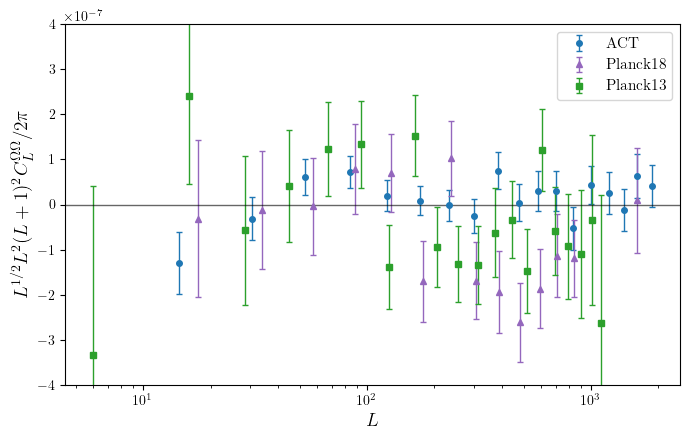

In [41]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for name, spec in datasets.items():
    mask = masks[name]
    ax.errorbar(
        spec.L[mask],
        spec.CL[mask] * cs.DR6_FACTOR(spec.L[mask]),
        yerr=spec.ER[mask] * cs.DR6_FACTOR(spec.L[mask]),
        label=name,
        capsize=2,
        lw=1,
        **plot_style[name],
    )

ax.axhline(0.0, color="black", lw=1, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel(r"$L$", fontsize=14)
ax.set_ylabel(r"$L^{1/2} L^2(L+1)^2 C_L^{\Omega \Omega}/{2\pi}$", fontsize=14)
ax.set_ylim(-4e-7, 4e-7)
ax.legend(fontsize=11)
fig.tight_layout()


In [42]:
Gmu_ref = 1.0e-4
P_fixed = 1.0
N_k = 30
max_workers = 8

CL_ref = {}
for name, spec in datasets.items():
    CL_ref[name] = cs.compute_cl(
        Gmu_ref,
        P_fixed,
        ell_arr=spec.L[masks[name]],
        N_k=N_k,
        max_workers=max_workers,
        progress=True,
    )


Computing Cl: 100%|██████████| 18/18 [00:01<00:00,  9.89it/s]
/Users/antoidicherianlonappan/Desktop/cosmic_strings/notebooks/../strings/cl.py:54: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner, _ = quad(inner_integrand, 0, chi_star, args=(k,), limit=200)
Computing Cl: 100%|██████████| 20/20 [00:00<00:00, 78471.54it/s]


In [43]:
def model_cl(dataset_name, Gmu):
    return CL_ref[dataset_name] * (Gmu / Gmu_ref)**2


def chi2_dataset(dataset_name, Gmu):
    spec = datasets[dataset_name]
    mask = masks[dataset_name]
    model = model_cl(dataset_name, Gmu)
    return np.sum(((spec.CL[mask] - model) / spec.ER[mask])**2)


def chi2_comparison(comparison_name, Gmu):
    return sum(
        chi2_dataset(dataset_name, Gmu)
        for dataset_name in comparisons[comparison_name]
    )


def upper_limit_from_chi2(chi2_func, delta_chi2=4.0, first_upper=3.0e-4):
    chi2_zero = chi2_func(0.0)

    def objective(Gmu):
        return chi2_func(Gmu) - chi2_zero - delta_chi2

    upper = first_upper
    while objective(upper) < 0:
        upper *= 2

    return brentq(objective, 0.0, upper)


upper_2sigma = {
    name: upper_limit_from_chi2(lambda Gmu, name=name: chi2_comparison(name, Gmu))
    for name in comparisons
}
upper_2sigma


{'ACT': 5.5723796316054893e-05,
 'Planck18': 0.00015867504479205022,
 'Planck13': 8.068976379910076e-05,
 'ACT+Planck18': 5.49695229819016e-05,
 'ACT+Planck13': 4.9693554023616805e-05}

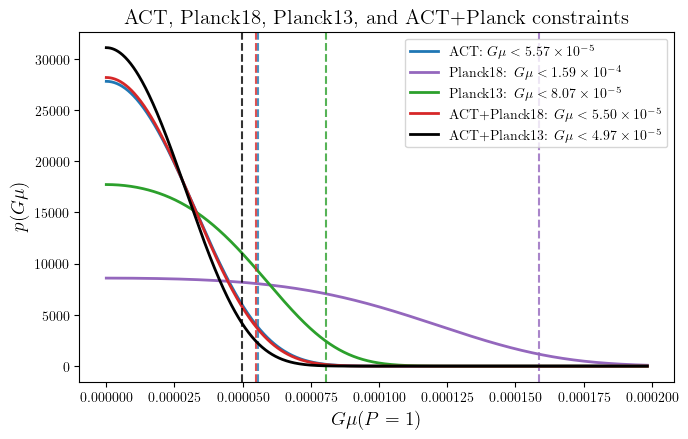

In [44]:
gmu_max = 1.25 * max(upper_2sigma.values())
gmu_grid = np.linspace(0.0, gmu_max, 800)

posterior = {}
for name in comparisons:
    chi2_zero = chi2_comparison(name, 0.0)
    delta_chi2 = np.array([
        chi2_comparison(name, Gmu) - chi2_zero
        for Gmu in gmu_grid
    ])
    p = np.exp(-0.5 * delta_chi2)
    posterior[name] = p / np.trapezoid(p, gmu_grid)

fig, ax = plt.subplots(figsize=(7, 4.5))

for name, p in posterior.items():
    limit = upper_2sigma[name]
    mantissa, exp = f"{limit:.2e}".split("e")
    label = rf"{name}: $G\mu < {mantissa}\times 10^{{{int(exp)}}}$"
    ax.plot(gmu_grid, p, lw=2, color=colors[name], label=label)
    ax.axvline(limit, color=colors[name], linestyle="--", lw=1.5, alpha=0.8)

ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.set_title(r"ACT, Planck18, Planck13, and ACT+Planck constraints", fontsize=15)
ax.legend(fontsize=10)
fig.tight_layout()


In [45]:
def log_prior(theta):
    Gmu = theta[0]
    if 0.0 < Gmu < 0.1:
        return 0.0
    return -np.inf


def log_likelihood_comparison(theta, comparison_name):
    Gmu = theta[0]
    if Gmu <= 0.0:
        return -np.inf
    return -0.5 * chi2_comparison(comparison_name, Gmu)


def log_probability_comparison(theta, comparison_name):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_comparison(theta, comparison_name)


In [46]:
# Optional MCMC version of the same CL likelihoods.
# The deterministic limits above are usually enough for a 1D comparison.
nwalkers = 20
ndim = 1
nsteps = 10000
initial_scale = 0.5 * max(upper_2sigma.values())
initial = initial_scale * (1.0 + 0.1 * np.random.randn(nwalkers, ndim))

samplers = {}
for name in comparisons:
    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        lambda theta, name=name: log_probability_comparison(theta, name),
    )
    sampler.run_mcmc(initial, nsteps, progress=True)
    samplers[name] = sampler


100%|██████████| 10000/10000 [00:03<00:00, 2783.31it/s]


In [47]:
samples = {
    name: sampler.get_chain(discard=500, thin=10, flat=True)[:, 0]
    for name, sampler in samplers.items()
}

upper_2sigma_mcmc = {
    name: np.percentile(values, 95)
    for name, values in samples.items()
}
upper_2sigma_mcmc


{'ACT': np.float64(5.2683455517496604e-05),
 'Planck18': np.float64(0.000141825387467782),
 'Planck13': np.float64(7.299394067858399e-05),
 'ACT+Planck18': np.float64(5.174825056034687e-05),
 'ACT+Planck13': np.float64(4.698834931012245e-05)}

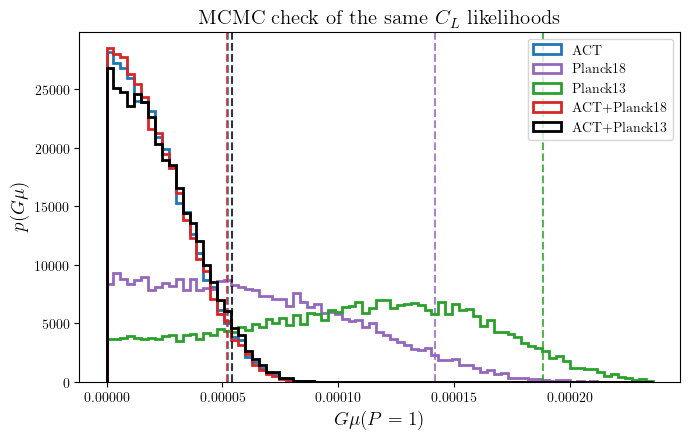

In [39]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bins = np.linspace(0.0, 1.25 * max(upper_2sigma_mcmc.values()), 80)
for name, values in samples.items():
    ax.hist(values, bins=bins, density=True, histtype="step", lw=2,
            color=colors[name], label=name)
    ax.axvline(upper_2sigma_mcmc[name], color=colors[name],
               linestyle="--", lw=1.5, alpha=0.8)

ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.set_title(r"MCMC check of the same $C_L$ likelihoods", fontsize=15)
ax.legend(fontsize=10)
fig.tight_layout()


Removed no burn in


Text(0.5, 5.808465514520197, '$G\\mu (P=1)$')

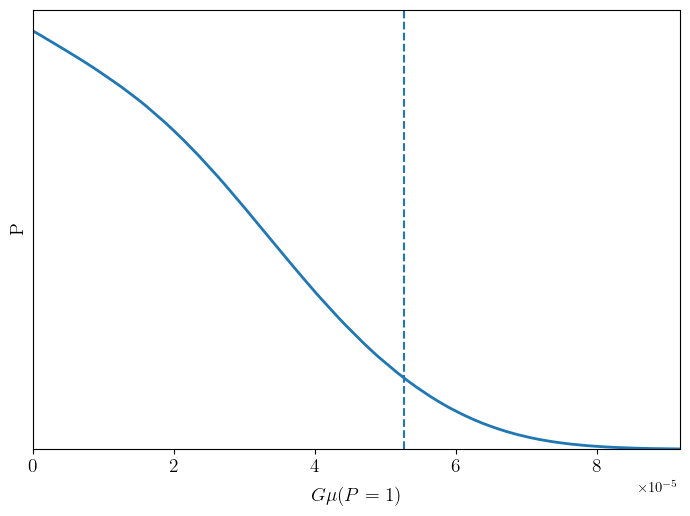

In [57]:
# ACT-only 1D posterior using getdist
try:
    from getdist import MCSamples, plots
except ImportError as exc:
    raise ImportError("getdist is required. Install it with: pip install getdist") from exc

act_samples = np.asarray(samples["ACT"]).reshape(-1, 1)
act_upper_95 = np.percentile(act_samples[:, 0], 95)

act_gd = MCSamples(
    samples=act_samples,
    names=["Gmu"],
    labels=[r"$G\mu$"],
    label="ACT",
    settings={"mult_bias_correction_order": 1}, ranges={"Gmu": [0, None]}

)

g = plots.get_single_plotter(width_inch=7)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 14
g.settings.legend_fontsize = 11
g.plot_1d(act_gd, "Gmu", normalized=True)
g.add_x_marker(act_upper_95, color=colors["ACT"], ls="--", lw=1.5, label=r"95\% upper limit")

ax = g.get_axes()
if ax.lines:
    ax.lines[0].set_color(colors["ACT"])

ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)

Removed no burn in
ACT 95% upper limit: Gmu < 5.268e-05


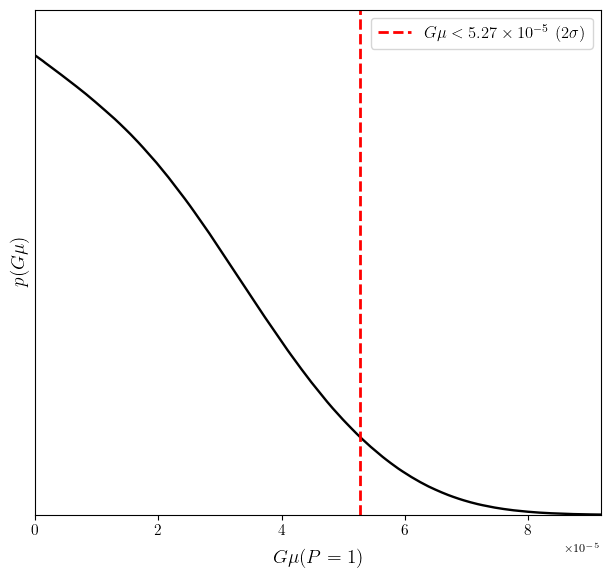

In [66]:
# ACT-only 1D posterior with getdist, following the requested plotting style
from getdist import MCSamples, plots

act_samples_1d = np.asarray(samples["ACT"])
gd_samples_act = MCSamples(
    samples=act_samples_1d.reshape(-1, 1),
    names=["gmu"],
    labels=[r"G\\mu"],
    label="ACT",
    settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)
upper_2sigma_act = np.percentile(act_samples_1d, 95)

g = plots.get_single_plotter(width_inch=6, ratio=1)
g.plot_1d(gd_samples_act, "gmu")
ax = plt.gca()
mantissa, exp = f"{upper_2sigma_act:.2e}".split("e")
constraint_latex = rf"$G\mu < {mantissa}\times 10^{{{int(exp)}}}$ (2$\sigma$)"
ax.axvline(
    upper_2sigma_act,
    color="red",
    linestyle="--",
    linewidth=2,
    label=constraint_latex,
 )
ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.legend(loc="upper right", fontsize=12)

print(f"ACT 95% upper limit: Gmu < {upper_2sigma_act:.3e}")
plt.savefig("plots/Gmu_Constraint_Plot.pdf", dpi=300, bbox_inches='tight')